# 07 · SHARP, AIA and GOES: the shared 72-hour experiment

## tl;dr
This notebook exports the exact cases, target and chronological roles needed to compare SHARP-only, AIA-only, GOES-only, SHARP+GOES, SHARP+AIA and SHARP+AIA+GOES. It checks agreement with the executed SHARP experiment, lists reusable image objects and creates GOES case requests.

**This is executed preparation, not AIA/GOES training or a fusion result.** Image references do not prove pixel integrity; a GOES source inventory is not a predictor matrix. The numerical summary below is generated from the pinned data. Full-population records retain missing inputs and unknown labels.

## Context & Methods
Use the original 72-hour primary-region M/X candidate target. Keep all fitting, model selection, probability calibration, uncertainty calibration and policy development in their reserved earlier blocks. Purge outcomes plus the existing assumed 24-hour reporting delay at role boundaries. The same native forecast cases are retained; this is not a new daily forecast schedule.

### Key assumptions
- Labels remain exploratory science-class/start-time candidates. Continuous negative-label coverage and historical delivery are not certified.
- Preserve native TAI issue times and the pinned UTC outcome endpoints: the 72-hour elapsed interval crosses leap seconds correctly, while naive UTC subtraction can differ by one second.
- Reuse raw AIA objects and compatible upstream code. A 48-hour score is not a 72-hour forecast, and a model fitted on later years cannot be used to generate leakage-free earlier calibration predictions.
- GOES future events supply labels; past continuous XRS measurements may supply global-context inputs. Satellite/detector choice, flags, history length and availability assumptions still need an accepted predictor specification.
- Freeze combination choices on earlier data; calibrate the combined output on the separate probability-calibration block. Later periods remain retrospective because they have already been inspected.
- Chronological roles do not establish AR/event-disjoint or prospective validation. Those require separately named evaluations.

### 1. Configuration
Run from the repository or its `notebooks/` directory using `requirements-training-lock.txt`. This preparation uses only local files, NumPy and pandas; importing the established SHARP role helper also requires PyTorch. The frozen dataset archive and parent SHARP outputs must be present. It does not download images, start GPU work or send messages to another chat.

In [1]:
from pathlib import Path
from datetime import datetime, timezone
import hashlib
import json
import sys
import numpy as np
import pandas as pd
from IPython.display import display, Markdown

REPO = Path.cwd().resolve()
if not (REPO / 'scripts' / 'prepare_multimodal72.py').exists():
    REPO = REPO.parent
assert (REPO / 'scripts' / 'prepare_multimodal72.py').is_file(), 'Run inside the Gray-Box repository'
sys.path.insert(0, str(REPO))
from scripts.prepare_multimodal72 import prepare, write_json, validate_prediction_import
from scripts.dataset_io import file_sha256
DATASET = REPO / 'data/processed/training_snapshot_20261002/gray_box_aligned_v1'
PARENT = REPO / 'outputs/sharp72_notebook_v1_20261002T080801721986Z'
TEMPORAL_CONFIG = REPO / 'configs/sharp72_temporal_v1.json'
OUTPUT = REPO / 'outputs' / ('multimodal72_preparation_v1_' + datetime.now(timezone.utc).strftime('%Y%m%dT%H%M%S%fZ'))
UPSTREAM = REPO.parent.parent / 'AIA Solar flare Project'
pd.set_option('display.max_columns', 12)
pd.set_option('display.width', 120)
print('New output:', OUTPUT)

New output: /Users/mac/Documents/ChatGPT/Imaging_Project/gray-box-solar-flare-forecasting/outputs/multimodal72_preparation_v1_20261002T165758076710Z


## Data
### 2. Export cases and reconcile the SHARP baseline
All package checksums, identity joins, label masks and history timestamps are checked. Every parent SHARP case must retain its exact role and label. Cases without assembled histories stay in the full-population file. The smaller comparison file is a **candidate** cohort pending actual AIA and GOES acceptance.

In [2]:
summary, cases, support, annual, images, contract = prepare(DATASET, PARENT, TEMPORAL_CONFIG, OUTPUT)
display(pd.DataFrame([{'Full population': summary['population_cases'],
                       'Candidate comparison cases': summary['candidate_comparison_cases'],
                       'SHARP rows reconciled': summary['parent_sharp_rows_reconciled'],
                       'Unique requested images': summary['unique_requested_aia_objects'],
                       'Model fits in this notebook': summary['model_fits']}]))
display(support.rename(columns={'candidate_sharp_aia': 'Candidate cases', 'positive_candidates': 'Positive candidate windows'}))

,Full population,Candidate comparison cases,SHARP rows reconciled,Unique requested images,Model fits in this notebook
0,153366,96596,113433,113037,0


,role,population,Candidate cases,Positive candidate windows,region_components,unknown_labels,missing_sharp_histories
0,train,38647,25586,1476,629,3912,10035
1,model_validation,6282,3905,416,99,1080,1586
2,probability_calibration,5018,2831,184,69,1445,1109
3,conformal_calibration,6196,4168,384,95,793,1454
4,policy_validation,18103,13142,422,313,519,4590
5,retrospective_cycle25,61383,35846,3860,943,12469,16061
6,supplementary_2026,14923,11118,992,128,1337,2764


### 3. Input roles and reusable upstream evidence
Read a bounded status snapshot from the existing AIA project, if available. These counts describe source processing at the saved timestamp, not complete XRS coverage or accepted predictors. Only derived status and source hashes are exported; no correspondence is copied.

In [3]:
upstream = {'snapshot_utc': datetime.now(timezone.utc).isoformat(), 'sources': {},
            'scope': 'Read-only source status; no upstream jobs launched or modified'}
legacy_path = UPSTREAM / 'run_records/19D_GOES_LEGACY_UNION_ARCHIVE_20261002.json'
if legacy_path.is_file():
    raw = legacy_path.read_bytes(); legacy = json.loads(raw)
    upstream['sources']['legacy_xrs'] = {'record': legacy_path.name, 'sha256': hashlib.sha256(raw).hexdigest(),
        'status': legacy['status'], 'predictors_created': legacy['predictors_created'],
        'historical_delivery_proven': legacy['historical_delivery_proven']}
state_path = UPSTREAM / 'inputs/goes_modern_native_inventory_20261002/state.json'
if state_path.is_file():
    raw = state_path.read_bytes(); state = json.loads(raw)
    upstream['sources']['modern_xrs'] = {'record': 'goes_modern_native_inventory_20261002/state.json',
        'sha256': hashlib.sha256(raw).hexdigest(), 'source_state_utc': state['updated_utc'],
        'files_in_inventory': len(state['records']), 'source_plan_sha256': state['plan_sha256'],
        'status': 'inventory snapshot; complete source review and predictor acceptance not inferred'}
write_json(OUTPUT / 'upstream_source_snapshot.json', upstream)
status_rows = [
    {'Component': 'SHARP', 'Here': '72-hour model fitted; frozen predictions available'},
    {'Component': 'AIA', 'Here': 'Past image references aligned; full pixel/model integration pending'},
    {'Component': 'GOES labels', 'Here': '72-hour candidate event outcomes in the frozen dataset'},
    {'Component': 'GOES predictors', 'Here': 'Past continuous XRS case requests exported; no accepted matrix here'},
]
display(pd.DataFrame(status_rows))
if 'modern_xrs' in upstream['sources']:
    r = upstream['sources']['modern_xrs']
    print(f"Upstream XRS inventory: {r['files_in_inventory']:,} file records at {r['source_state_utc']}; not model readiness.")
else:
    print('Upstream snapshot unavailable here; the portable preparation remains valid.')

,Component,Here
0,SHARP,72-hour model fitted; frozen predictions avail...
1,AIA,Past image references aligned; full pixel/mode...
2,GOES labels,72-hour candidate event outcomes in the frozen...
3,GOES predictors,Past continuous XRS case requests exported; no...


Upstream XRS inventory: 2,797 file records at 2026-10-02T16:58:09.764772+00:00; not model readiness.


## Results
### 4. Population and candidate support by year
Candidate support requires known labels, finite SHARP histories, past ordered AIA references and an eligible chronological role. It does not require a GOES measurement that has not yet been imported. The full population retains 2020 issues, but there are no eligible 2020 comparison cases under the frozen input/split contract.

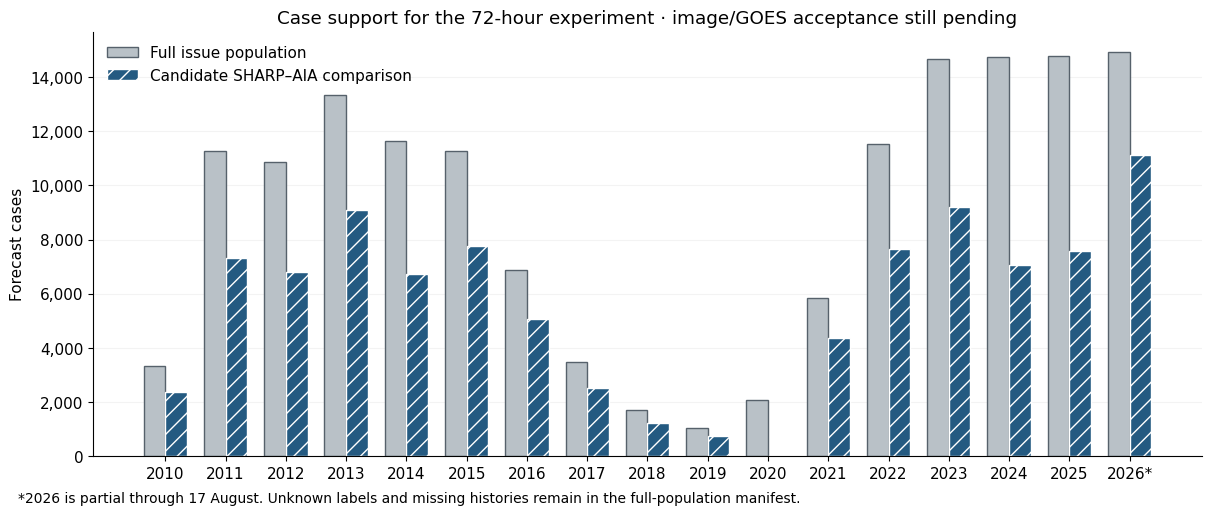

,year,population,candidate_sharp_aia,sharp_histories,known_labels
0,2010,3316,2377,2377,3316
1,2011,11277,7317,8554,9697
2,2012,10855,6818,7944,9377
3,2013,13333,9074,9833,12406
4,2014,11653,6736,8881,9128
5,2015,11259,7764,8549,10229
6,2016,6885,5052,5052,6851
7,2017,3462,2518,2705,3214
8,2018,1711,1213,1213,1711
9,2019,1058,763,763,1058


Candidate cases: 96,596; this is not the final three-input evaluation denominator.


In [4]:
import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter
plt.rcParams.update({'font.size': 11, 'axes.spines.top': False, 'axes.spines.right': False})
plot = annual.set_index('year').reindex(range(int(annual.year.min()), int(annual.year.max()) + 1), fill_value=0)
fig, ax = plt.subplots(figsize=(12, 4.8), layout='constrained')
x = np.arange(len(plot))
ax.bar(x-.18, plot.population, .36, label='Full issue population', color='#B9C1C7', edgecolor='#56616B')
ax.bar(x+.18, plot.candidate_sharp_aia, .36, label='Candidate SHARP–AIA comparison', color='#245A81', hatch='//', edgecolor='white')
ax.set(xticks=x, xticklabels=[str(y) if y != 2026 else '2026*' for y in plot.index], ylabel='Forecast cases',
       title='Case support for the 72-hour experiment · image/GOES acceptance still pending')
ax.yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))
ax.grid(axis='y', alpha=.15); ax.set_axisbelow(True); ax.legend(frameon=False, loc='upper left')
fig.text(.01, -.035, '*2026 is partial through 17 August. Unknown labels and missing histories remain in the full-population manifest.', fontsize=10)
fig.savefig(OUTPUT / 'candidate_support_by_year.png', dpi=160, bbox_inches='tight')
plt.show()
display(annual)
print(f"Candidate cases: {summary['candidate_comparison_cases']:,}; this is not the final three-input evaluation denominator.")

### 5. Reuse images and request past GOES measurements
The image inventory deduplicates objects across overlapping forecast histories. Blank generation/hash fields are requests for exact source receipts, not verification claims. The GOES request file specifies case IDs and observation cutoffs; it contains no invented flux values. Input availability times remain a separate requirement for an operational replay.

In [5]:
display(pd.DataFrame([
    {'Item': 'AIA history references', 'Count': summary['aia_history_references']},
    {'Item': 'Unique requested AIA objects', 'Count': summary['unique_requested_aia_objects']},
    {'Item': 'GOES case requests', 'Count': summary['candidate_comparison_cases']},
    {'Item': 'New remote downloads', 'Count': summary['downloads']},
]))
preview = cases[cases.candidate_sharp_aia_comparison].groupby('role', sort=False).head(1)
display(preview[['source_sample_id', 'role', 'issue_utc', 'label']].reset_index(drop=True))
print('Full tables:', OUTPUT / 'candidate_comparison_cases.csv.gz')

,Item,Count
0,AIA history references,289788
1,Unique requested AIA objects,113037
2,GOES case requests,96596
3,New remote downloads,0


,source_sample_id,role,issue_utc,label
0,20100522_0036_HARP26_NOAA11072,train,2010-05-22 00:35:26+00:00,0
1,20140102_1212_HARP3557_NOAA11938,model_validation,2014-01-02 12:11:25+00:00,0
2,20140701_0048_HARP4302_NOAA12105,probability_calibration,2014-07-01 00:47:25+00:00,0
3,20150101_0112_HARP5002_NOAA12251,conformal_calibration,2015-01-01 01:11:25+00:00,0
4,20150701_1424_HARP5736_NOAA12377,policy_validation,2015-07-01 14:23:24+00:00,0
5,20210114_0224_HARP7532_NOAA12796,retrospective_cycle25,2021-01-14 02:23:23+00:00,0
6,20260102_0500_HARP14228_NOAA14331,supplementary_2026,2026-01-02 04:59:23+00:00,0


Full tables: /Users/mac/Documents/ChatGPT/Imaging_Project/gray-box-solar-flare-forecasting/outputs/multimodal72_preparation_v1_20261002T165758076710Z/candidate_comparison_cases.csv.gz


### 6. Reconcile saved SHARP predictions on the requested cases
This checks the integration interface using already-executed raw SHARP probabilities. It does not refit, select thresholds or inspect new performance scores. For future branches, the interface rejects changed targets/splits, silent case loss, future observations and probabilities assigned to failed inputs. Declarations and hashes alone do not prove the actual model fit; checkpoint/provenance review remains necessary.

In [6]:
parent_predictions = pd.read_csv(PARENT / 'predictions.csv.gz', float_precision='round_trip')
requested = cases[cases.candidate_sharp_aia_comparison]
anchor = requested[['forecast_case_id', 'history_96_UTC']].merge(
    parent_predictions[['forecast_case_id', 'probability_gru_mean']], on='forecast_case_id', validate='one_to_one')
anchor = anchor.rename(columns={'history_96_UTC': 'last_observation_utc', 'probability_gru_mean': 'probability'})
anchor['input_status'] = 'ok'
metadata = {k: contract[k] for k in ['horizon_hours','target_scope','target_version','dataset_manifest_sha256',
    'split_manifest_sha256','training_case_ids_sha256','probability_kind','fit_roles','selection_roles']}
metadata.update(branch='sharp', historical_availability='unverified_retrospective', combiner_fit_roles=[])
anchor_check = validate_prediction_import(anchor, metadata, contract, cases)
write_json(OUTPUT / 'sharp_import_check.json', anchor_check)
display(pd.DataFrame([anchor_check]))
rejections = []
for name, changes in [('Old 48-hour target', {'horizon_hours': 48}),
                      ('Different chronological split', {'split_manifest_sha256': 'different'}),
                      ('Model fitted on later evaluation data', {'fit_roles': ['train','retrospective_cycle25']})]:
    try:
        validate_prediction_import(anchor, {**metadata, **changes}, contract, cases)
    except ValueError as error:
        rejections.append({'Incompatible import': name, 'Result': str(error)})
    else:
        raise AssertionError('Incompatible import was accepted')
display(pd.DataFrame(rejections))

,status,cases,issued,input_failures,historical_availability
0,structural_checks_passed_not_scientific_accept...,96596,96596,0,unverified_retrospective


,Incompatible import,Result
0,Old 48-hour target,Prediction contract mismatch: horizon_hours
1,Different chronological split,Prediction contract mismatch: split_manifest_s...
2,Model fitted on later evaluation data,Fitting/selection roles differ from the matche...


### 7. Model comparison and information boundaries
The added SHARP+GOES control helps distinguish GOES's contribution without AIA. For the main GOES comparison, evaluate SHARP+AIA again on exactly the triple-input cases; otherwise changing case coverage can masquerade as a modelling improvement. Whole-population availability is reported separately.

In [7]:
display(pd.DataFrame([
    {'Model': 'SHARP-only', 'Purpose': 'Existing magnetic baseline'},
    {'Model': 'AIA-only', 'Purpose': 'Image information alone'},
    {'Model': 'GOES-only', 'Purpose': 'Past full-disk XRS context baseline'},
    {'Model': 'SHARP+GOES', 'Purpose': 'GOES addition without the image branch'},
    {'Model': 'SHARP+AIA', 'Purpose': 'Two-source fusion reference'},
    {'Model': 'SHARP+AIA+GOES', 'Purpose': 'GOES added to the same SHARP+AIA cases'},
]))
display(pd.DataFrame(contract['blocks']))
print(contract['training_case_policy'])
print(contract['late_fusion'])

,Model,Purpose
0,SHARP-only,Existing magnetic baseline
1,AIA-only,Image information alone
2,GOES-only,Past full-disk XRS context baseline
3,SHARP+GOES,GOES addition without the image branch
4,SHARP+AIA,Two-source fusion reference
5,SHARP+AIA+GOES,GOES added to the same SHARP+AIA cases


,role,start,end
0,train,2010-01-01,2014-01-01
1,model_validation,2014-01-01,2014-07-01
2,probability_calibration,2014-07-01,2015-01-01
3,conformal_calibration,2015-01-01,2015-07-01
4,policy_validation,2015-07-01,2020-01-01
5,retrospective_cycle25,2021-01-01,2026-01-01
6,supplementary_2026,2026-01-01,2027-01-01


Exact matched training IDs required; input failures require a versioned protocol amendment and matched refits, not silent dropping.
Fixed equal probability average reference; any learned combiner uses model_validation only. Fit calibration afterward on probability_calibration.


## Takeaways
### 8. Save the preparation receipt
The next compute phase is a **72-hour AIA training run with these exact roles**, after source bytes, preprocessing, cache capacity and a bounded real-data loader/model check are established. Upstream XRS source collection can continue independently. Its accepted raw source work can be reused, but the final GOES predictor specification and aligned tensor are still needed before GOES or three-source training.

No new AIA/GOES model, fusion improvement, operational readiness or independent future validation is claimed by this notebook.

In [8]:
receipt = {'status': 'completed_preparation_not_training',
           'completed_utc': datetime.now(timezone.utc).isoformat(),
           'population_cases': summary['population_cases'],
           'candidate_cases': summary['candidate_comparison_cases'],
           'sharp_import': anchor_check, 'expected_rejections': len(rejections),
           'model_fits': 0, 'remote_downloads': 0,
           'artifacts': {p.name: file_sha256(p) for p in sorted(OUTPUT.iterdir()) if p.is_file()}}
write_json(OUTPUT / 'notebook_receipt.json', receipt)
display(Markdown(f"**Prepared {summary['candidate_comparison_cases']:,} candidate cases from {summary['population_cases']:,} total cases.** "
                 f"Reconciled {summary['parent_sharp_rows_reconciled']:,} parent SHARP rows. "
                 'AIA/GOES fitting and full pixel/predictor acceptance remain pending.'))
print('Saved receipt:', OUTPUT / 'notebook_receipt.json')

**Prepared 96,596 candidate cases from 153,366 total cases.** Reconciled 113,433 parent SHARP rows. AIA/GOES fitting and full pixel/predictor acceptance remain pending.

Saved receipt: /Users/mac/Documents/ChatGPT/Imaging_Project/gray-box-solar-flare-forecasting/outputs/multimodal72_preparation_v1_20261002T165758076710Z/notebook_receipt.json
